# Goldman Sachs (GS) Stock Analysis (1999–2026)

This project analyzes Goldman Sachs stock data over multiple decades.

Objectives:
- Explore long-term stock trends
- Analyze volatility and returns
- Detect crashes and market regimes
- Build technical indicators
- Forecast stock prices using machine learning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("archive(1)/gs_barchart.csv")

df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce")
df["Date"] = df["Date"].dt.tz_localize(None)

df = df.sort_values("Date")

df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Source
0,1999-05-04 04:00:00,52.313516,53.173936,48.183502,48.441628,22320900,0.0,0.0,Barchart (via proxy)
1,1999-05-05 04:00:00,48.097432,48.097432,45.602216,47.581181,7565700,0.0,0.0,Barchart (via proxy)
2,1999-05-06 04:00:00,46.806815,47.753276,46.161500,46.763794,2905700,0.0,0.0,Barchart (via proxy)
3,1999-05-07 04:00:00,46.763814,51.539144,45.946415,51.022892,4862300,0.0,0.0,Barchart (via proxy)
4,1999-05-10 04:00:00,50.506625,50.592667,48.355576,48.656723,2589400,0.0,0.0,Barchart (via proxy)


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (6755, 9)
<class 'pandas.DataFrame'>
RangeIndex: 6755 entries, 0 to 6754
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          6755 non-null   datetime64[us]
 1   Open          6755 non-null   float64       
 2   High          6755 non-null   float64       
 3   Low           6755 non-null   float64       
 4   Close         6755 non-null   float64       
 5   Volume        6755 non-null   int64         
 6   Dividends     6755 non-null   float64       
 7   Stock Splits  6755 non-null   float64       
 8   Source        6755 non-null   str           
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 475.1 KB


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,6755,6755.000000,6755.000000,6755.000000,6755.000000,6.755000e+03,6755.000000,6755.0
mean,2012-10-04 05:01:47.653590,176.922202,179.019100,174.869033,176.993077,4.831152e+06,0.014119,0.0
min,1999-05-04 04:00:00,38.802315,39.449020,35.162555,38.417725,1.076000e+05,0.000000,0.0
25%,2006-01-19 17:00:00,77.979144,79.319540,77.135961,78.252079,2.251350e+06,0.000000,0.0
50%,2012-10-02 04:00:00,130.379943,131.888195,128.912189,130.332138,3.232600e+06,0.000000,0.0
75%,2019-06-20 16:00:00,192.110245,193.575133,190.262802,191.912186,5.073350e+06,0.000000,0.0
max,2026-03-11 04:00:00,967.906158,979.544918,951.989921,970.751160,1.145907e+08,4.500000,0.0
std,NaN,153.017700,154.807085,151.347238,153.171924,5.723973e+06,0.166345,0.0


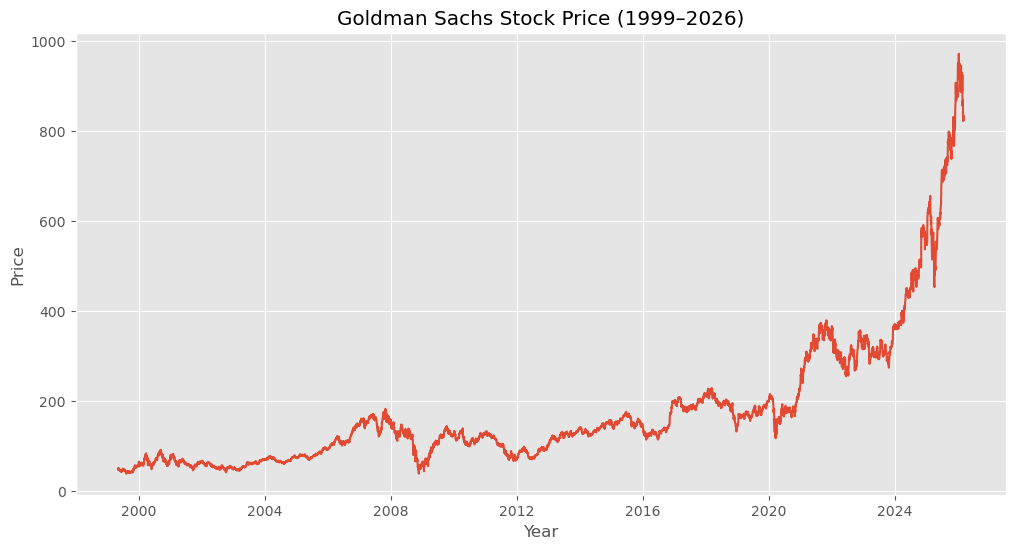

In [5]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"])

plt.title("Goldman Sachs Stock Price (1999–2026)")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

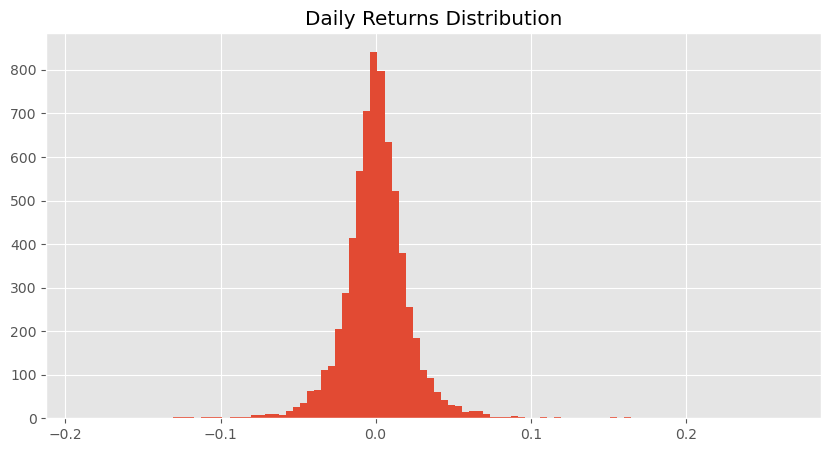

In [6]:
df["returns"] = df["Close"].pct_change()

plt.figure(figsize=(10,5))

df["returns"].hist(bins=100)

plt.title("Daily Returns Distribution")

plt.show()

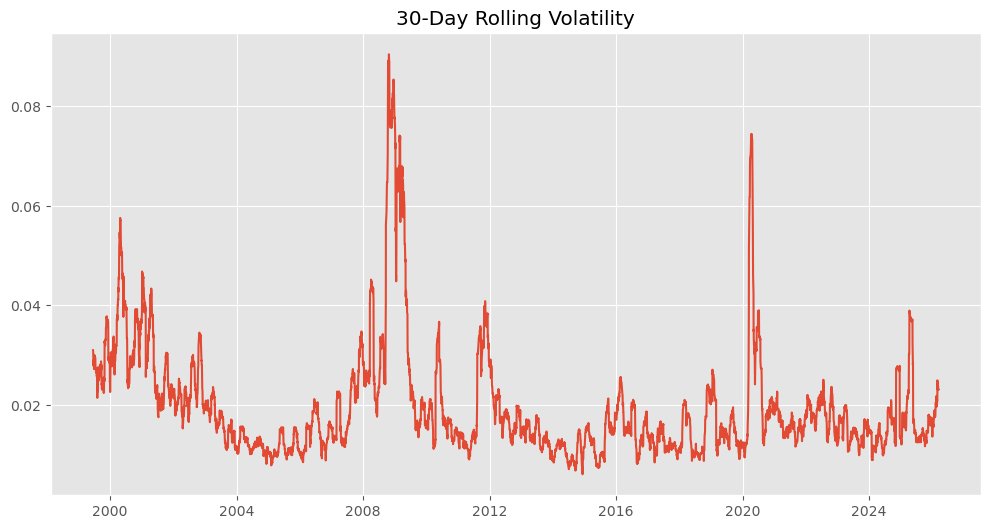

In [7]:
df["volatility"] = df["returns"].rolling(30).std()

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["volatility"])

plt.title("30-Day Rolling Volatility")

plt.show()

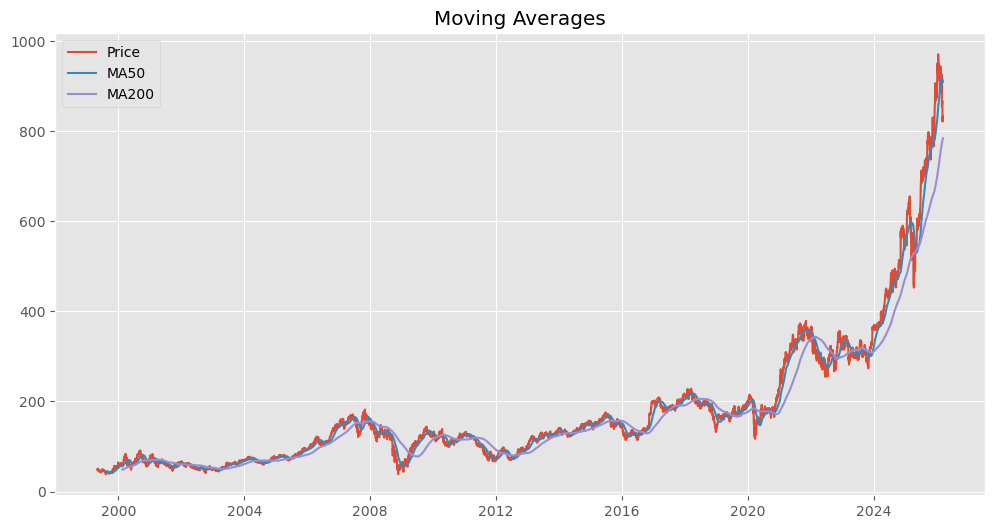

In [8]:
df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"], label="Price")
plt.plot(df["Date"], df["MA50"], label="MA50")
plt.plot(df["Date"], df["MA200"], label="MA200")

plt.legend()

plt.title("Moving Averages")

plt.show()

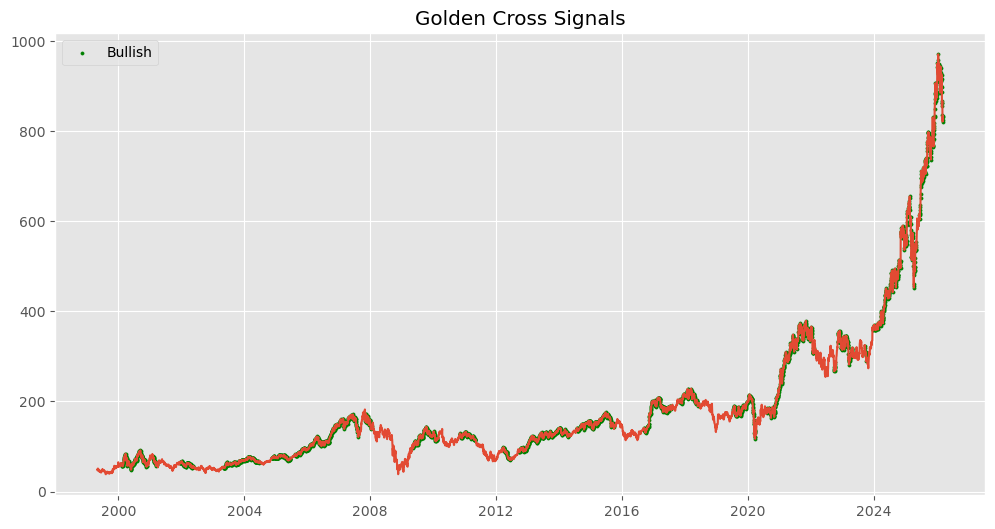

In [9]:
df["signal"] = 0
df.loc[df["MA50"] > df["MA200"], "signal"] = 1

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"])

plt.scatter(
    df[df["signal"] == 1]["Date"],
    df[df["signal"] == 1]["Close"],
    color="green",
    s=5,
    label="Bullish"
)

plt.legend()

plt.title("Golden Cross Signals")

plt.show()

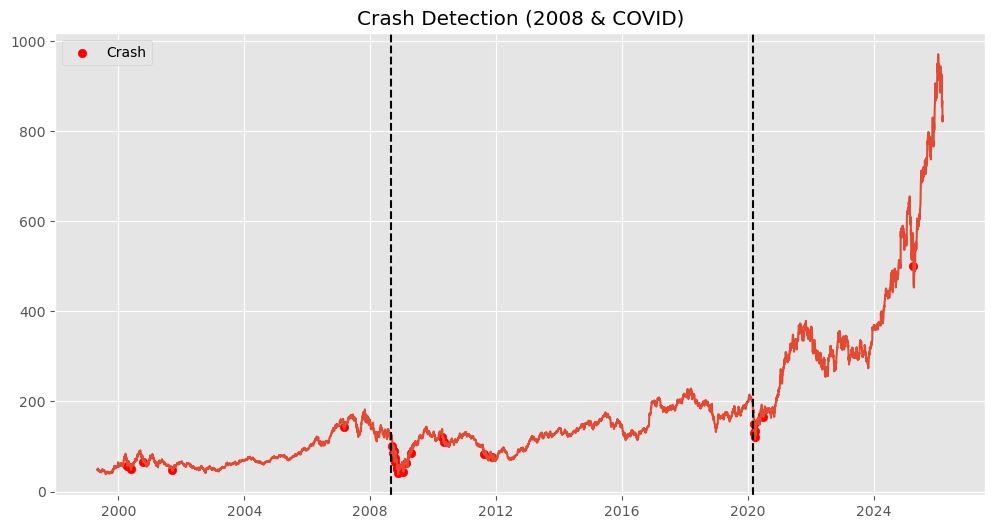

In [10]:
df["returns_pct"] = df["returns"] * 100

crashes = df[df["returns_pct"] < -8]

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"])

plt.scatter(
    crashes["Date"],
    crashes["Close"],
    color="red",
    label="Crash"
)

plt.axvline(pd.to_datetime("2008-09-01"), color="black", linestyle="--")
plt.axvline(pd.to_datetime("2020-03-01"), color="black", linestyle="--")

plt.title("Crash Detection (2008 & COVID)")
plt.legend()

plt.show()

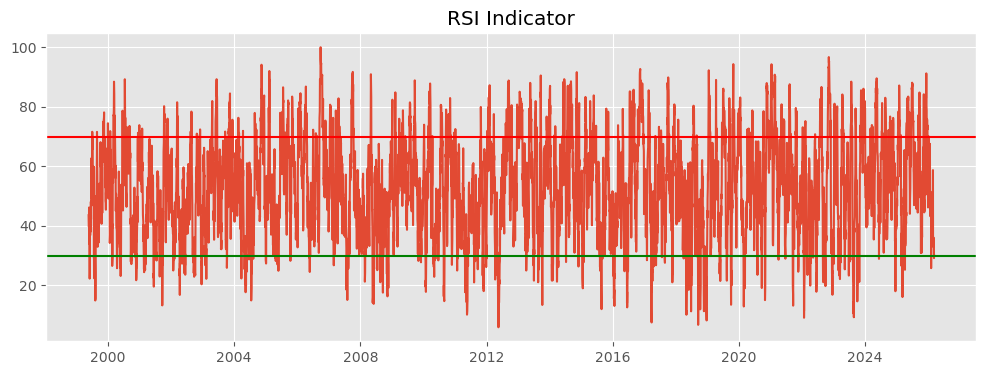

In [11]:
delta = df["Close"].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss

df["RSI"] = 100 - (100 / (1 + rs))

plt.figure(figsize=(12,4))

plt.plot(df["Date"], df["RSI"])

plt.axhline(70, color="red")
plt.axhline(30, color="green")

plt.title("RSI Indicator")

plt.show()

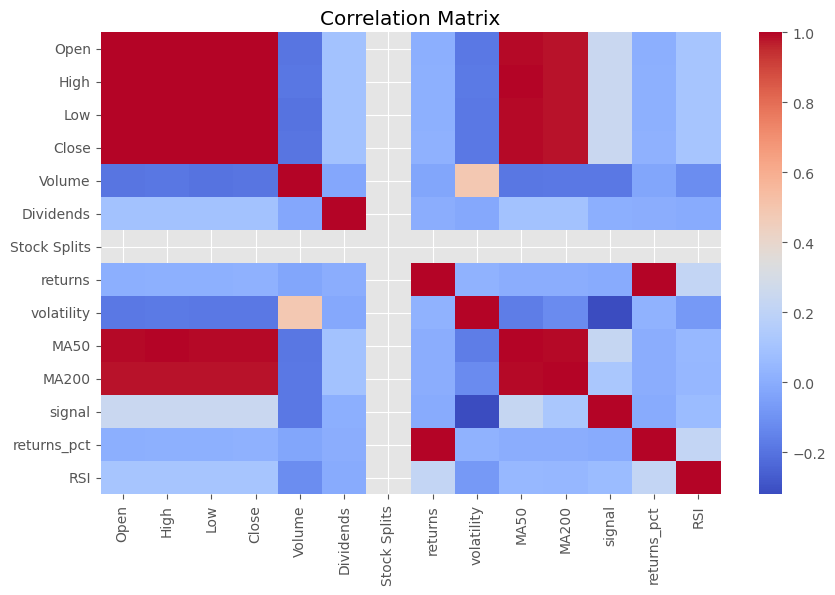

In [12]:

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [13]:
df_ml = df.dropna()

features = ["Open","High","Low","Volume","MA50","MA200","RSI"]

X = df_ml[features]

y = df_ml["Close"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
pred = model.predict(X_test)

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 2.2504391784214013
R2: 0.9997615799364004


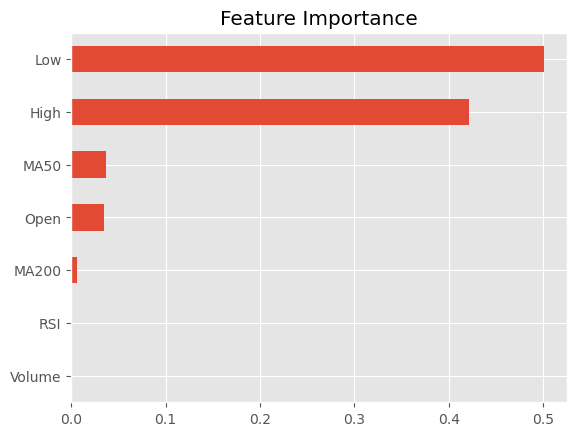

In [18]:
importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()

In [19]:
print("Date Range:", df["Date"].min(), "-", df["Date"].max())
print("Total Records:", len(df))

Date Range: 1999-05-04 04:00:00 - 2026-03-11 04:00:00
Total Records: 6755
